<h1> Project 1- Supervised Classification </h1>
<p> The next step after finishing collecting data was to analyze the data. The first thing I need to do was to classify every comment so I can analyze the comments accordingly. The stream of my analysis will be explained as follows. </p>
<p> First, I retrieved data from the database and organized them into pandas DataFrame. </p>
<p> Second, I selected only English comments for the analysis. I also performed text cleaning, which is to allow a more precise and intelligible prediction result. </p>
<p> Third, I sampled 200 comments from the dataset for supervised classification. I wrote a program to make the manual classification more friendly. Three variables with boolean values were designed based on the research scope. These three variables were quality, national-ethnic, and K-Pop. For example, if the comment was about the quality of the music video or the K-Pop group, the comment was coded 1 under the class quality. If it was not about the quality, then the comment was coded 0. The logic was the same for variable national-ethnic and variable  K-Pop as well. </p>
<p> Forth, I performed Naive Bayes Classification with tf-idf text vectorization. I have tried using the word-to-vector model and TensorFlow for the classification, but I decided to use tf-idf at the end because, in this particular project, an intelligible classification model is very important. Therefore, I prepared an evaluation section below every classification model with visualization to make sense of the classification model. </p>
<p> Fifth, I analyzed the count of each class and the group distribution by class with visualization. </p>

<h2> Retreve Data From the Database </h2>

In [1]:
from mysql.connector import connect, Error

import pandas as pd
import numpy as np
import re
import random

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
### connection parameters

h = 'localhost'
u = 'root'
pw = 'chunjuihsu'

In [3]:
#
# retrive data for use
#

In [4]:
### find the names of the tables that store comment data

sql = """ SELECT song_name FROM video_list"""

try:
    with connect(host=h, user=u, password=pw, database='who_can_be_kpop') as connection:
        
        with connection.cursor() as cursor:            
            cursor.execute(sql)
            
            # why [0]?
            song_name_list = [item[0] for item in cursor.fetchall()]
                
except Error as e:
    print(e)
    
comment_table_name_list = list()

for song_name in song_name_list:
    
    new_song_name = re.sub(' ', '_', song_name)
    table_name = 'comment_'+new_song_name
    comment_table_name_list.append(table_name)

In [5]:
all_comment = pd.DataFrame()

for table in comment_table_name_list:
    
    select_query = """
    
        SELECT `%s`.comment, `%s`.author, group_list.group_name
        
        FROM `%s`
        
        INNER JOIN video_list
        
        ON `%s`.video_id = video_list.id
        
        INNER JOIN group_list
        
        ON video_list.group_id = group_list.id       
        
        """
    
    replace_tuple = (table, table, table, table)
    
    try:
        with connect(host=h, user=u, password=pw, database='who_can_be_kpop') as connection:
        
            with connection.cursor() as cursor:            
                cursor.execute(select_query % replace_tuple)
            
                comment = pd.DataFrame(cursor.fetchall())
                
                all_comment = all_comment.append(comment)
                
    except Error as e:
        print(e)

<h2> Text Cleaning </h2>

In [6]:
from langdetect import detect
import nltk
#nltk.download('all')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

In [7]:
def good_language_detect(text):
    try:
        language = detect(text)
        return(language)
    except:
        return(np.nan)
    
lemmatizer = WordNetLemmatizer()
    
def text_cleaner(text, remove_special_characters):
    
    if remove_special_characters == True:
        text = re.sub('[^a-zA-Z]', ' ', text)
    
    text = text.lower()
    text = re.sub('k-pop', 'kpop', text)
    text = re.sub('k pop', 'kpop', text)
    text = word_tokenize(text)
    text = [t for t in text if len(t)>1]
    text = [lemmatizer.lemmatize(word) for word in text if not word in set(stopwords.words('english'))]
        
    text = ' '.join(text)
    
    text = re.sub('gon na ', 'go ', text)
    text = re.sub('wan na ', 'want ', text)
    
    return(text)

In [8]:
all_comment = all_comment.reset_index(drop=True)

all_comment.columns = ['comment', 'author', 'group']

####### making all columns that will be used in the future for the data structure consistency

all_comment['processed_comment']    = np.nan
all_comment['quality']              = np.nan
all_comment['national-ethnic']      = np.nan
all_comment['kpop']                 = np.nan

all_comment['language'] = all_comment['comment'].apply(lambda x: good_language_detect(x))

####### preparing the actual dataset that will be anaylized

eng_comment = all_comment.loc[all_comment['language']=='en', :]

data = eng_comment.copy()
data['processed_comment'] = data['comment'].apply(lambda x: text_cleaner(x, True))

<h3> the following cell presents a snippet of the data structure for the data to classify </h3>

In [9]:
data.head()

,comment,author,group,processed_comment,quality,national-ethnic,kpop,language
0,imagine asking for exo tickets for your birthd...,Annaliese Bain,exp edition,imagine asking exo ticket birthday mom get ins...,NaN,NaN,NaN,en
1,i wanna know what kpop idols think about this,johnhyuck,exp edition,want know kpop idol think,NaN,NaN,NaN,en
2,They're not terrible at singing or anything bu...,Katherine Wells,exp edition,terrible singing anything think need kpop much...,NaN,NaN,NaN,en
3,those weird crying pictures are terrifying wtf,Emily T,exp edition,weird cry picture terrifying wtf,NaN,NaN,NaN,en
4,"so i'm waiting for btx, eighteen, monsta z, go...",maya,exp edition,waiting btx eighteen monsta got debut,NaN,NaN,NaN,en


<h2> A Program I Wrote to Facilitate Mannual Classification </h2>

<p> In this jupyter notebook, I set the sample size to three as an example to show how the program work. In the actual analysis, the sample size was set to 200. </p>

In [10]:
def classify_facilitator(dataframe, sample_size):
    
    #
    #  dataframe is a panda dataframe that contains comments to classify
    #  this function will sample 200 comments from the given dataframe
    #  and provide easy way and insturction for researchers to code any presented comment 
    #

    tt_set = dataframe.sample(sample_size).copy()

    counter = 0

    for i, r in tt_set.iterrows():
    
        print(r['comment'])
        classifier = input('input accordingly with comma: (quality, national-ethnic, kpop)')
    
        try:
            a_list = classifier.split(",")
            a_tuple = tuple(a_list)
    
            q, n, k = a_tuple
        
            dataframe.loc[i, 'quality']          = q
            dataframe.loc[i, 'national-ethnic']  = n
            dataframe.loc[i, 'kpop']             = k
            
        except:
            
            q, n, k = (np.nan, np.nan, np.nan)

            dataframe.loc[i, 'quality']          = q
            dataframe.loc[i, 'national-ethnic']  = n
            dataframe.loc[i, 'kpop']             = k
    
        counter += 1
        
        print('----encoded-'+str(counter)+'comment----')
    
    return(dataframe)

In [11]:
data = classify_facilitator(data, 3)

Their voices give me a thousand years of life


input accordingly with comma: (quality, national-ethnic, kpop) 1, 0, 0


----encoded-1comment----
I LOVE YOU UHSN DUBET JUSEYO🙏


input accordingly with comma: (quality, national-ethnic, kpop) 0, 0, 0


----encoded-2comment----
Oh my god, Let's go to 1m! Please


input accordingly with comma: (quality, national-ethnic, kpop) 0, 0, 0


----encoded-3comment----


<h3> save the classification result to pandas pickle so I don't need to do it again next time  </h3>

In [12]:
#data.to_pickle('NB-classification.pickle')

<h2> Naive Bayes Classification with TF-IDF Text Vectorization </h2>

<h3> read the pandas pickle that was previously stored </h3>

In [13]:
data = pd.read_pickle('NB-classification.pickle')
data = data[data['processed_comment'].notnull()].copy()

<h3> tt_set refers the train_test_dataset, while data refers to the total dataset that contains also comments that were not classified yet. </h3>

In [14]:
tt_set = data[data['quality'].notnull()].copy()
tt_set.head()

,comment,author,group,processed_comment,quality,national-ethnic,kpop,language
13,Guys come on where's the eyeliner?,Peizhou Shi,exp edition,guy come eyeliner,0,0,0,en
43,Korean People want to be like americans and am...,Eda Akin,exp edition,korean people want like american american want...,0,1,0,en
65,Fighting! I'm proud of you guys,Jae Riot,exp edition,fighting proud guy,0,0,0,en
77,This is a big dip in quality. The guys clearly...,gunther stewart,exp edition,big dip quality guy clearly talent think manag...,1,0,0,en
103,this is like when ur grandma accidentally buys...,richie rich,exp edition,like ur grandma accidentally buy tappy toe ins...,0,0,0,en


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn import metrics
from sklearn.metrics import accuracy_score

<h3> the below cell defines four functions that help understand the classification model through visualization </h3>

In [16]:
def top_tfidf_feats(row, features, top_n=25):
    ''' Get top n tfidf values in row and return them with their corresponding feature names.'''

    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    
    df = pd.DataFrame(top_feats)
    df.columns = ['feature', 'tfidf']
    return df

def top_feats_in_doc(Xtr, features, row_id, top_n=25):
    ''' Top tfidf features in specific document (matrix row) '''
    row = np.squeeze(Xtr[row_id].toarray())
    return top_tfidf_feats(row, features, top_n)

def top_mean_feats(Xtr, features, grp_ids=None, min_tfidf=0.1, top_n=25):
    ''' Return the top n features that on average are most important amongst documents in rows
        indentified by indices in grp_ids. '''
    if grp_ids:
        D = Xtr[grp_ids].toarray()
    else:
        D = Xtr.toarray()

    D[D < min_tfidf] = 0
    tfidf_means = np.mean(D, axis=0)
    return top_tfidf_feats(tfidf_means, features, top_n)

def top_feats_by_class(Xtr, y, features, min_tfidf=0.1, top_n=25):
    ''' Return a list of dfs, where each df holds top_n features and their mean tfidf value
        calculated across documents with the same class label. '''
    dfs = []
    labels = np.unique(y)
    for label in labels:
        ids = np.where(y==label)
        feats_df = top_mean_feats(Xtr, features, ids, min_tfidf=min_tfidf, top_n=top_n)
        feats_df.label = label
        dfs.append(feats_df)
    df0, df1 = tuple(dfs)
    return df0, df1

In [17]:
# classifing quality

while True:

    x_train, x_test, y_train, y_test = train_test_split(tt_set['processed_comment'], tt_set['quality'])
    
    vectorizer = TfidfVectorizer(stop_words='english')
    
    x_train_tfidf = vectorizer.fit_transform(x_train)
    
    haters_class = BernoulliNB().fit(x_train_tfidf, y_train)

    x_test_tfidf = vectorizer.transform(x_test)

    pred = haters_class.predict(x_test_tfidf)

    accu_score = accuracy_score(y_test, pred)
    
    if accu_score > 0.80:   #select models with accuracy score higher than 0.8
        
        if len(np.unique(pred)) == 2:     #to avoid preduction of any class is 0
            
            print('classification report for class quality:')
            print('')
            print(metrics.classification_report(y_test, pred))
               
            x = data['processed_comment']
            x_tfidf = vectorizer.transform(x)
        
            pre = haters_class.predict(x_tfidf)
            data['quality'] = pre
            
            break
        
        continue
        
    else:
        continue

classification report for class quality:

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.89      0.81      0.85        21

    accuracy                           0.88        50
   macro avg       0.88      0.87      0.88        50
weighted avg       0.88      0.88      0.88        50



<h3> evaluating the quality classification model with visualization </h3>

In [18]:
features = vectorizer.get_feature_names()
_0, _1 = top_feats_by_class(x_tfidf, data['quality'].values, features, min_tfidf=0.1, top_n=25)

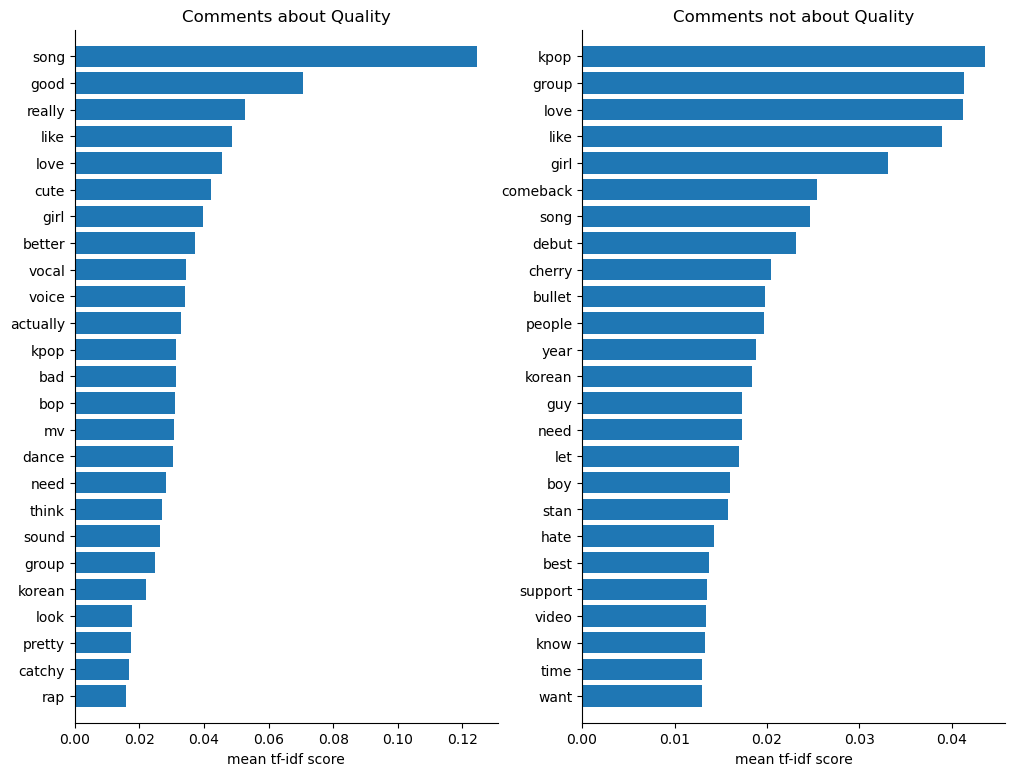

In [19]:
y_1 = _1['feature']
x_1 = _1['tfidf']

y_0 = _0['feature']
x_0 = _0['tfidf']

fig, axs = plt.subplots(1, 2, figsize=(12, 9))
barh1 = axs[0].barh(y_1, x_1)
barh2 = axs[1].barh(y_0, x_0)

axs[0].set_title('Comments about Quality')
axs[0].set_xlabel('mean tf-idf score')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_ylim([-1, 25])
axs[0].invert_yaxis()

axs[1].set_title('Comments not about Quality')
axs[1].set_xlabel('mean tf-idf score')
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_ylim([-1, 25])
axs[1].invert_yaxis()

plt.show()

<h3> Interpretation </h3>

<p> 1. The figure shows the words with the 25 highest mean tf-idf score that naive bayes algorithm takes into consideration in comments classified as about quality and comments classified as not. </p>
<p> 2. The model successfully captures the words about quality. Words such as song, voice, mv, and dance represent the different aspects of quality of a K-Pop group, whereas good, cute, bad, better, catchy are words to describe the qualities. </p>

In [20]:
# classifing national-ethnic

while True:

    x_train, x_test, y_train, y_test = train_test_split(tt_set['processed_comment'], tt_set['national-ethnic'])
    
    vectorizer = TfidfVectorizer(stop_words='english')
    
    x_train_tfidf = vectorizer.fit_transform(x_train)
    
    haters_class = BernoulliNB().fit(x_train_tfidf, y_train)

    x_test_tfidf = vectorizer.transform(x_test)

    pred = haters_class.predict(x_test_tfidf)

    accu_score = accuracy_score(y_test, pred)
    
    if accu_score > 0.80:    #select models with accuracy score higher than 0.8
        
        if len(np.unique(pred)) == 2:     #to avoid preduction of any class is 0
            
            print('classification report for class national-ethnic:')
            print('')
            print(metrics.classification_report(y_test, pred))
               
            x = data['processed_comment']
            x_tfidf = vectorizer.transform(x)
        
            pre = haters_class.predict(x_tfidf)
            data['national-ethnic'] = pre
            
            break
        
        continue
        
    else:
        continue

classification report for class national-ethnic:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        44
           1       1.00      0.33      0.50         6

    accuracy                           0.92        50
   macro avg       0.96      0.67      0.73        50
weighted avg       0.93      0.92      0.90        50



<h3> evaluating the national-ethnic classification model with visualization </h3>

In [21]:
features = vectorizer.get_feature_names()
_0, _1 = top_feats_by_class(x_tfidf, data['national-ethnic'].values, features, min_tfidf=0.1, top_n=25)

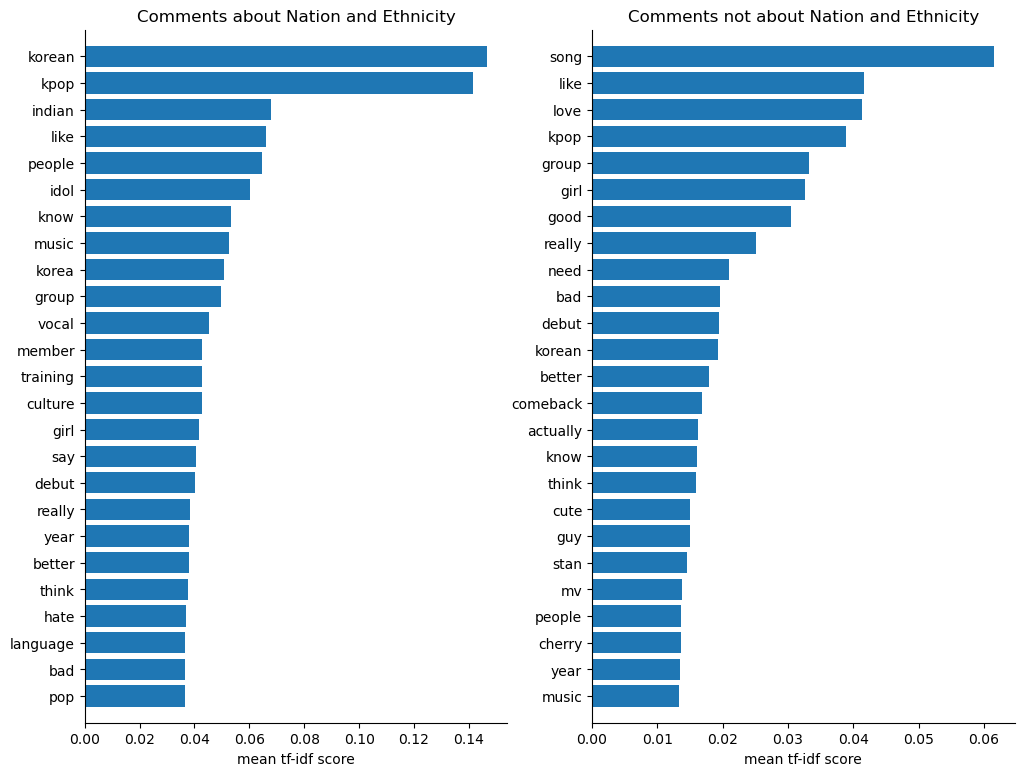

In [22]:
y_1 = _1['feature']
x_1 = _1['tfidf']

y_0 = _0['feature']
x_0 = _0['tfidf']

fig, axs = plt.subplots(1, 2, figsize=(12, 9))
barh1 = axs[0].barh(y_1, x_1)
barh2 = axs[1].barh(y_0, x_0)

axs[0].set_title('Comments about Nation and Ethnicity')
axs[0].set_xlabel('mean tf-idf score')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_ylim([-1, 25])
axs[0].invert_yaxis()

axs[1].set_title('Comments not about Nation and Ethnicity')
axs[1].set_xlabel('mean tf-idf score')
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_ylim([-1, 25])
axs[1].invert_yaxis()

plt.show()

<h3> Interpretation </h3>

<p> 1. The figure shows the words with the 25 highest mean tf-idf score that naive bayes algorithm takes into consideration in comments classified as about national-ethnic and comments classified as not. </p>
<p> 2. The model successfully captures the words about national-ethnic. Words such as korean, korea, indian, culture, and language are words about national-ethnic. </p>
<p> 3. Meanwhile, it is interesting to see which words are in the left figure but are not in the right figure, for example, hate and training, which we can assume have high co-occurrence in the comments about national-ethnic topics. </p>

In [24]:
# classifing kpop

while True:

    x_train, x_test, y_train, y_test = train_test_split(tt_set['processed_comment'], tt_set['kpop'])
    
    vectorizer = TfidfVectorizer(stop_words='english')
    
    x_train_tfidf = vectorizer.fit_transform(x_train)
    
    haters_class = BernoulliNB().fit(x_train_tfidf, y_train)

    x_test_tfidf = vectorizer.transform(x_test)

    pred = haters_class.predict(x_test_tfidf)

    accu_score = accuracy_score(y_test, pred)
    
    if accu_score > 0.80:    #select model with only accuracy score more than 0.8
        
        if len(np.unique(pred)) == 2:     #to avoid preduction of any class is 0
            
            print('classification report for class kpop:')
            print('')
            print(metrics.classification_report(y_test, pred))
               
            x = data['processed_comment']
            x_tfidf = vectorizer.transform(x)
        
            pre = haters_class.predict(x_tfidf)
            data['kpop'] = pre
            
            break
        
        continue
        
    else:
        continue

classification report for class kpop:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        44
           1       1.00      0.17      0.29         6

    accuracy                           0.90        50
   macro avg       0.95      0.58      0.62        50
weighted avg       0.91      0.90      0.87        50



<h3> evaluating the kpop classification model with visualization </h3>

In [26]:
features = vectorizer.get_feature_names()
_0, _1 = top_feats_by_class(x_tfidf, data['kpop'].values, features, min_tfidf=0.1, top_n=25)

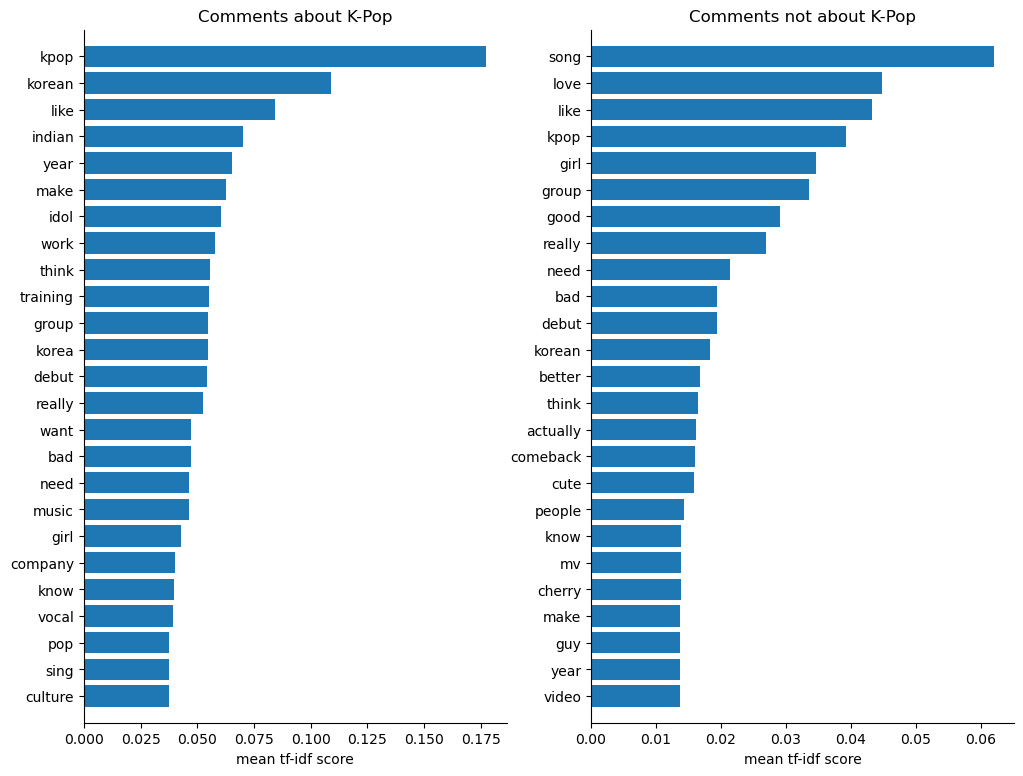

In [27]:
y_1 = _1['feature']
x_1 = _1['tfidf']

y_0 = _0['feature']
x_0 = _0['tfidf']

fig, axs = plt.subplots(1, 2, figsize=(12, 9))
barh1 = axs[0].barh(y_1, x_1)
barh2 = axs[1].barh(y_0, x_0)

axs[0].set_title('Comments about K-Pop')
axs[0].set_xlabel('mean tf-idf score')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_ylim([-1, 25])
axs[0].invert_yaxis()

axs[1].set_title('Comments not about K-Pop')
axs[1].set_xlabel('mean tf-idf score')
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_ylim([-1, 25])
axs[1].invert_yaxis()

plt.show()

<h3> Interpretation </h3>

<p> 1. The figure shows the words with the 25 highest mean tf-idf score that naive bayes algorithm takes into consideration in comments classified as about kpop and comments classified as not. </p>
<p> 2. The model successfully captures the words about K-Pop, as can be seen, that kpop ranked the top in the figure on the left-hand side. The high score of korean suggested K-Pop fans associated K-Pop as being Korean.</p>
<p> 3. However, when considering my strategy to classify kpop class was to code all comments with the occurrence of the kpop as 1, this prediction model didn't work as expected because the word kpop still ranked very high in comments that the machine considered not about K-Pop. </p>

<h3> store the classification result as pandas pickle for future analysis </h3>

In [30]:
#data.to_pickle('data_with_class.pickle')

<h2> Analyzed Count of Each Class and Group Distribution by Class with Visualization </h2>

<h3> retrieve classification result pickle </h3>

In [44]:
data = pd.read_pickle('data_with_class.pickle') 

In [45]:
data['quality'] = data['quality'].astype(int)
data['national-ethnic'] = data['national-ethnic'].astype(int)
data['kpop'] = data['kpop'].astype(int)

<h3> class count </h3>

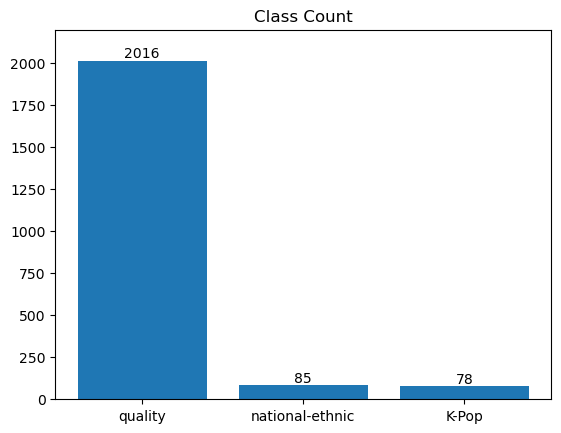

In [46]:
quality = data['quality'].values.tolist().count(1)
ne = data['national-ethnic'].values.tolist().count(1)
kpop = data['kpop'].values.tolist().count(1)

labels = ['quality', 'national-ethnic', 'K-Pop']
y = [quality, ne, kpop]

fig, ax = plt.subplots()
bar = ax.bar(labels, y)

ax.set_title('Class Count')
ax.set_ylim([0, 2200])
ax.bar_label(bar)

plt.show()

<h3> Interpretation </h3>

<p> 1. There were much more comments classified as about quality, wherea comments about national-ethnic and kpop were much less. </p>
<p> 2. This should be the consequence of having a small train dataset. I personally think there should be at least around 200 comments that can be classified as kpop and national-ethnic. </p>

<h3> group distribution by class </h3>

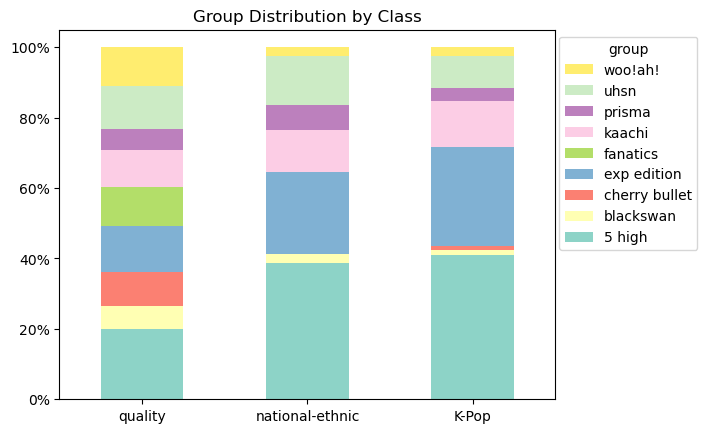

In [47]:
q = data.groupby('quality')['group'].value_counts(normalize=True).sort_index()[1]
n = data.groupby('national-ethnic')['group'].value_counts(normalize=True).sort_index()[1]
k = data.groupby('kpop')['group'].value_counts(normalize=True).sort_index()[1]

group = data['group'].value_counts().sort_index().index

quality = q*100
ne = n*100
kpop = k*100

df = pd.DataFrame(index=['quality', 'national-ethnic', 'K-Pop'], columns=group)
df.loc['quality'] = quality
df.loc['national-ethnic'] = ne
df.loc['K-Pop'] = kpop

df = df.fillna(0)
df = df.reset_index()

ax = df.plot(x='index', kind='bar', stacked=True, cmap='Set3')

ax.set_title('Group Distribution by Class')

ax.set_xlabel('')
ax.set_xticklabels(['quality', 'national-ethnic', 'K-Pop'], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='group', loc=1, bbox_to_anchor=(1.3, 1.00))

plt.show()

<h3> Interpretation </h3>

<p> 1. The figure shows the distribution of groups in each class. </p>
<p> 2.While in class quality, the group distribution was relatively equal, it was interesting to see in class national-ethnic and K-Pop that some groups occupied the most proportion and others barely had any representation. </p>
<p> 3. 5 High, EXP Edition, and KAACHI, claimed K-Pop groups that were entiredly made of non-Korean members and were produced entirely outside of Korea, generated the most discussions about national-ethnic and about K-Pop. On the other hand, in the music video of K-Pop groups with only Asian members such as cherry bullet, fanatics, and woo!ah!, there were barely people commenting anything about national-ethnic and K-Pop. </p>